# Exploratory Data Analysis

## Project
AI-Powered Factory Reallocation & Shipping Optimization Recommendation System for Nassau Candy Distributor

## Objective
The objective of this notebook is to explore the Nassau Candy Distributor dataset and identify business patterns related to sales, profit, products, regions, customers, and shipping performance.

The insights generated in this notebook will support feature engineering, predictive modeling, factory optimization, and the final recommendation system.

## Business Context
Before recommending better factory-product assignments, it is important to understand how the business currently performs.

This analysis investigates historical order behavior, product demand, profitability, shipping modes, regional performance, and potential operational inefficiencies.

In [23]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)

print("Libraries imported successfully.")

Libraries imported successfully.


In [24]:
data_path = Path("../data/raw")
csv_file = list(data_path.glob("*.csv"))[0]

df = pd.read_csv(csv_file)

print("Dataset loaded sucessfully")
print(f"Dataset shape: {df.shape}")

Dataset loaded sucessfully
Dataset shape: (10194, 18)


In [25]:
df["Order Date"] = pd.to_datetime(df["Order Date"], format="mixed", dayfirst=True)
df["Ship Date"] = pd.to_datetime(df["Ship Date"], format="mixed", dayfirst=True)

df["Shipping Lead Time"] = (df["Ship Date"] - df["Order Date"]).dt.days

df["Order Year"] = df["Order Date"].dt.year
df["Order Month"] = df["Order Date"].dt.month
df["Order Month Name"] = df["Order Date"].dt.month_name()
df["Order Quarter"] = df["Order Date"].dt.quarter

df["Profit Margin (%)"] = (df["Gross Profit"] / df["Sales"]) * 100
df["Profit per Unit"] = df["Gross Profit"] / df["Units"]

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost,Shipping Lead Time,Order Year,Order Month,Order Month Name,Order Quarter,Profit Margin (%),Profit per Unit
0,1,US-2021-103800-CHO-MIL-31000,2024-01-03,2026-06-30,Standard Class,103800,United States,Houston,Texas,77095,Chocolate,Interior,CHO-MIL-31000,Wonka Bar - Milk Chocolate,6.50,2,4.22,2.28,909,2024,1,January,1,64.923077,2.11
1,2,US-2021-112326-CHO-TRI-54000,2024-01-04,2026-07-01,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,7.50,2,4.90,2.60,909,2024,1,January,1,65.333333,2.45
2,3,US-2021-112326-CHO-NUT-13000,2024-01-04,2026-07-01,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,10.47,3,7.47,3.00,909,2024,1,January,1,71.346705,2.49
3,4,US-2021-112326-CHO-SCR-58000,2024-01-04,2026-07-01,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,10.80,3,7.50,3.30,909,2024,1,January,1,69.444444,2.50
4,5,US-2021-141817-CHO-TRI-54000,2024-01-05,2026-07-05,Standard Class,141817,United States,Philadelphia,Pennsylvania,19143,Chocolate,Atlantic,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,11.25,3,7.35,3.90,912,2024,1,January,1,65.333333,2.45


In [26]:
figures_path = Path("../reports/figures")
figures_path.mkdir(parents=True, exist_ok=True)

print("Figures folder ready.")

Figures folder ready.


## Dataset Completeness Analysis

### Business Question

Does the dataset contain missing information that could affect downstream analysis and predictive modeling?

Missing values can reduce model accuracy, introduce bias, and require preprocessing strategies before feature engineering.

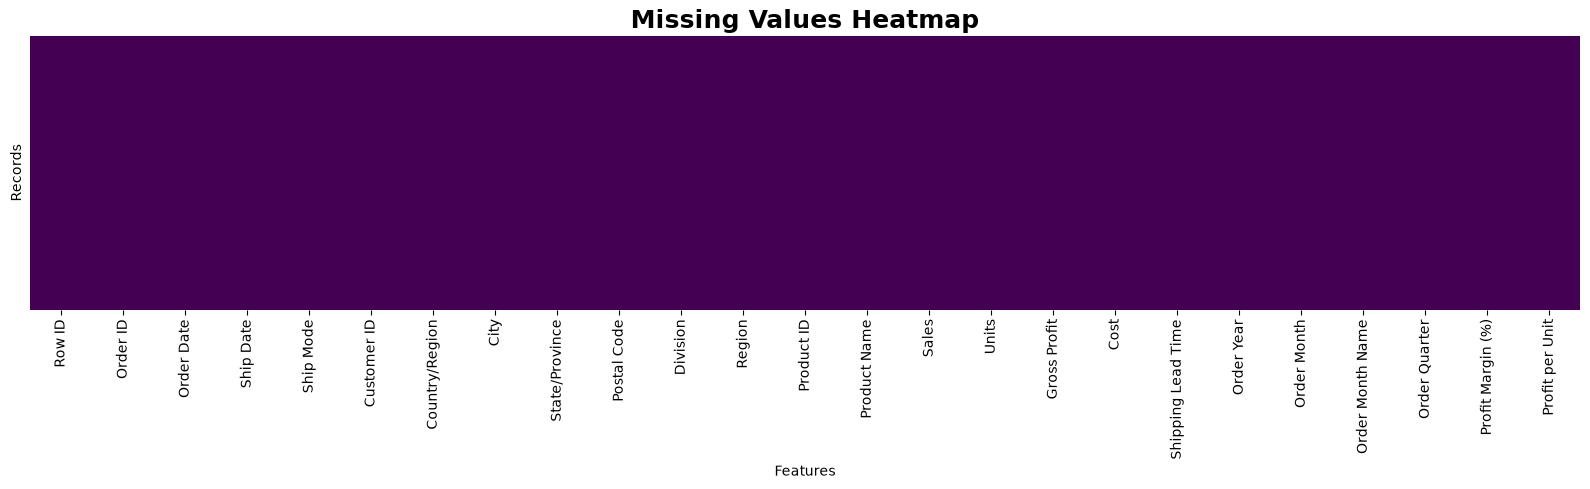

In [27]:
plt.figure(figsize=(16, 5))

sns.heatmap(
    df.isnull(),
    cbar=False,
    cmap="viridis",
    yticklabels=False
)

plt.title("Missing Values Heatmap", fontsize=18, fontweight="bold")
plt.xlabel("Features")
plt.ylabel("Records")

plt.tight_layout()

plt.savefig(
    figures_path/"missing_values_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation

The heatmap provides a visual overview of missing values across all features.

Dark vertical bands indicate columns with missing observations, while uniformly colored columns represent complete data.

### Business Interpretation

Understanding data completeness is the first step toward building reliable predictive models.

If important operational variables contain missing values, appropriate imputation strategies will be required before machine learning.

## Missing Values Summary

### Business Question

Which variables contain missing values and how significant is the missingness?

In [28]:
missing = (
    df.isnull()
      .sum()
      .sort_values(ascending=False)
)

missing = missing[missing > 0]

if len(missing) == 0:
    print("✅ No missing values found in the dataset.")
else:
    plt.figure(figsize=FIG_SIZE)

    missing.plot(kind="bar")

    plt.title("Missing Values per Feature",
              fontsize=TITLE_SIZE,
              fontweight="bold")

    plt.ylabel("Missing Count")

    plt.tight_layout()

    plt.savefig(
        figures_path/"missing_values_summary.png",
        dpi=DPI,
        bbox_inches="tight"
    )

    plt.show()

missing

✅ No missing values found in the dataset.


Series([], dtype: int64)

### Observation

No missing values were detected in any feature of the dataset.

Therefore, no data imputation or missing-value treatment is required before exploratory analysis or machine learning.

### Business Interpretation

A complete dataset improves confidence in downstream analyses and predictive modeling.

Since operational records are fully populated, analytical results are less likely to be biased due to incomplete information.

In [29]:
summary = pd.DataFrame({
    "Metric":[
        "Rows",
        "Columns",
        "Numeric Features",
        "Categorical Features"
    ],
    "Value":[
        df.shape[0],
        df.shape[1],
        df.select_dtypes(include=np.number).shape[1],
        df.select_dtypes(exclude=np.number).shape[1]
    ]
})

summary

,Metric,Value
0,Rows,10194
1,Columns,25
2,Numeric Features,12
3,Categorical Features,13


### Observation

The dataset now contains 10,194 transaction records and 25 analytical features.

Feature engineering increased the original dataset from 18 to 25 variables by creating additional business-oriented attributes such as shipping lead time, temporal variables, profit margin, and profit per unit.

The dataset consists of:

- 12 numerical variables
- 13 categorical variables

This provides a balanced mix of quantitative and categorical information for exploratory analysis and predictive modeling.

### Business Interpretation

The engineered features enrich the business information available for analysis.

Temporal variables allow seasonal demand analysis, shipping lead time enables logistics performance evaluation, and profitability metrics improve financial decision-making.

Overall, the dataset is now better suited for discovering operational insights and training predictive machine learning models.

### Business Question

What is the composition of the dataset after feature engineering?

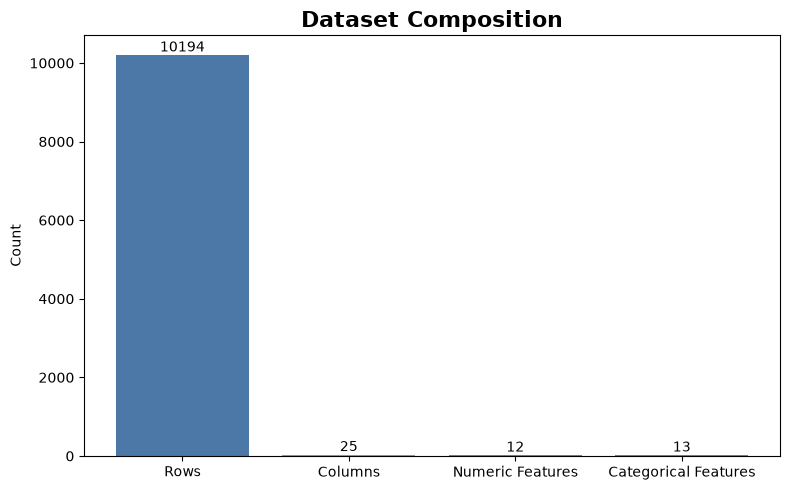

In [30]:
plt.figure(figsize=(8,5))

plt.bar(
    summary["Metric"],
    summary["Value"],
    color=["#4C78A8","#F58518","#54A24B","#E45756"]
)

plt.title(
    "Dataset Composition",
    fontsize=16,
    fontweight="bold"
)

plt.ylabel("Count")

for i, value in enumerate(summary["Value"]):
    plt.text(i, value+100, str(value), ha="center")

plt.tight_layout()

plt.savefig(
    figures_path/"dataset_composition.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation

The visualization shows that the dataset contains over ten thousand transaction records with a rich collection of engineered variables.

The number of numerical and categorical features is well balanced, indicating that both statistical analysis and categorical segmentation can be performed effectively.

### Business Interpretation

A balanced feature composition supports multiple analytical techniques, including descriptive analytics, customer segmentation, profitability analysis, and predictive machine learning.

The engineered dataset provides sufficient diversity to model operational efficiency and business performance from multiple perspectives.

### Business Question

Which candy products generate the highest sales revenue?

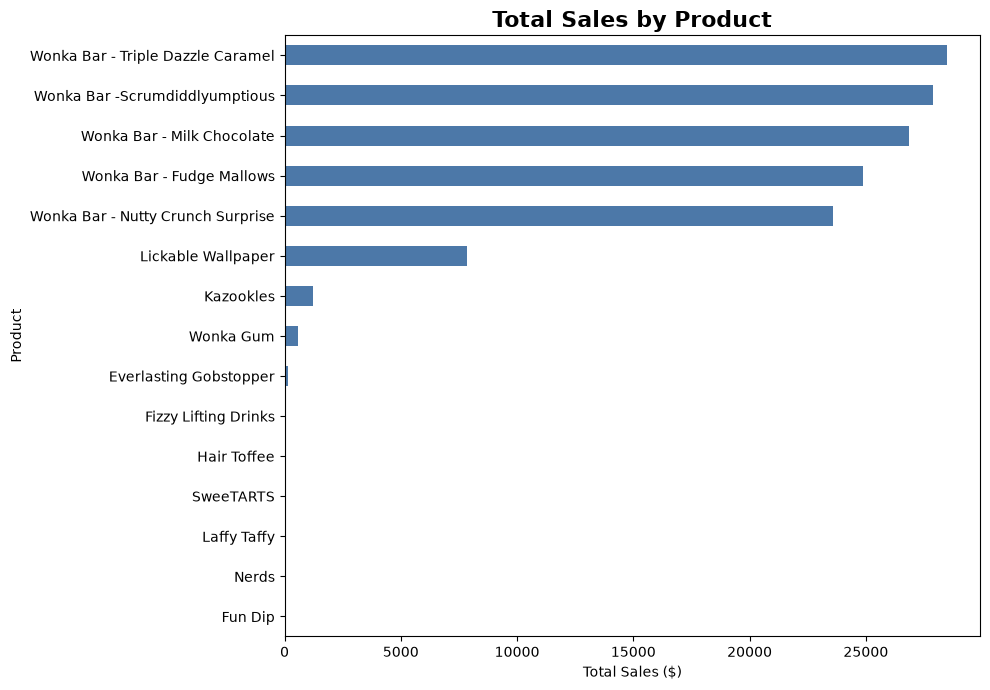

In [32]:
sales_product = (
    df.groupby("Product Name")["Sales"]
      .sum()
      .sort_values()
)

plt.figure(figsize=(10,7))

sales_product.plot(
    kind="barh",
    color="#4C78A8"
)

plt.title(
    "Total Sales by Product",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Total Sales ($)")
plt.ylabel("Product")

plt.tight_layout()

plt.savefig(
    figures_path/"sales_by_product.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation

The sales distribution is highly concentrated among a small number of products.

Five Wonka products contribute the majority of total sales, while several niche products generate comparatively little revenue.

This indicates an uneven product portfolio where demand is dominated by a few flagship products.

### Business Interpretation

The business should prioritize production planning and inventory allocation for the highest-selling Wonka products to avoid stock shortages.

Low-selling products should be evaluated for promotional campaigns, pricing optimization, or possible discontinuation if they consistently contribute little revenue.

## Business Question

Which products contribute the most gross profit to the business?

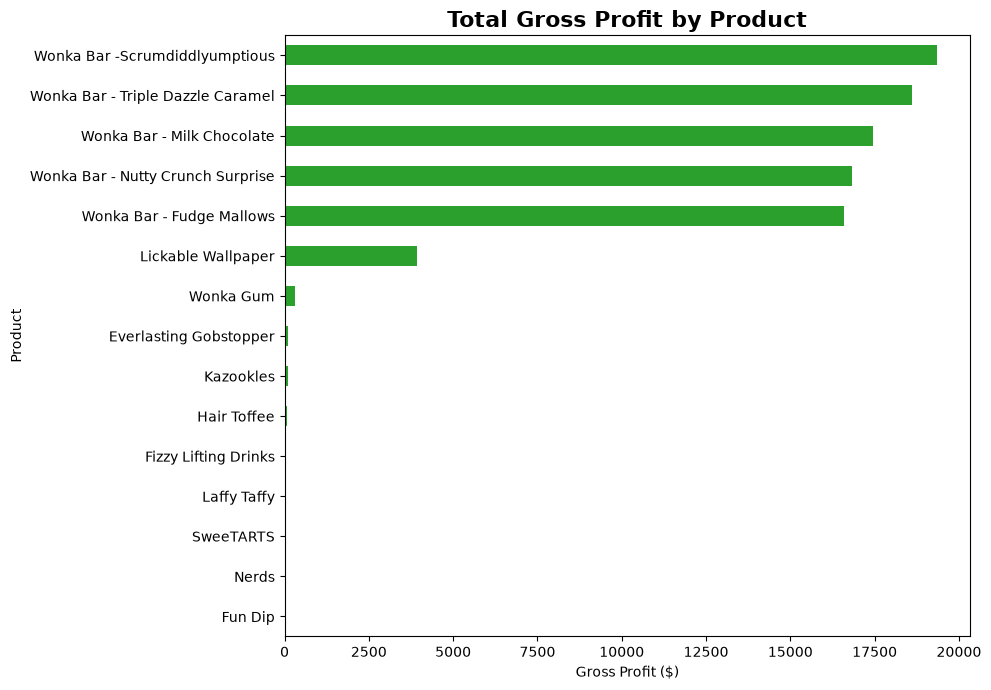

Product Name
Wonka Bar -Scrumdiddlyumptious       19357.50
Wonka Bar - Triple Dazzle Caramel    18610.20
Wonka Bar - Milk Chocolate           17443.37
Wonka Bar - Nutty Crunch Surprise    16819.95
Wonka Bar - Fudge Mallows            16593.60
Lickable Wallpaper                    3930.00
Wonka Gum                              310.70
Everlasting Gobstopper                 104.00
Kazookles                               92.75
Hair Toffee                             59.50
Fizzy Lifting Drinks                    47.25
Laffy Taffy                             33.48
SweeTARTS                               28.70
Nerds                                    7.00
Fun Dip                                  4.80
Name: Gross Profit, dtype: float64

In [33]:
profit_product = (
    df.groupby("Product Name")["Gross Profit"]
      .sum()
      .sort_values()
)

plt.figure(figsize=(10,7))

profit_product.plot(
    kind="barh",
    color="#2CA02C"
)

plt.title(
    "Total Gross Profit by Product",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Gross Profit ($)")
plt.ylabel("Product")

plt.tight_layout()

plt.savefig(
    figures_path/"profit_by_product.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

profit_product.sort_values(ascending=False)

### Observation

Gross profit is concentrated among a small group of flagship Wonka products.

The same products that dominate revenue also generate the highest overall profit, while several niche products contribute only marginal profitability.

This indicates a highly concentrated profit distribution across the product portfolio.

### Business Interpretation

Products generating the highest gross profit should receive priority in production planning, inventory allocation, and marketing investment.

Products with consistently low profitability should be evaluated for pricing improvements, promotional strategies, or possible discontinuation if operational costs outweigh their contribution.

## Business Question

Which geographical regions contribute the highest sales revenue?

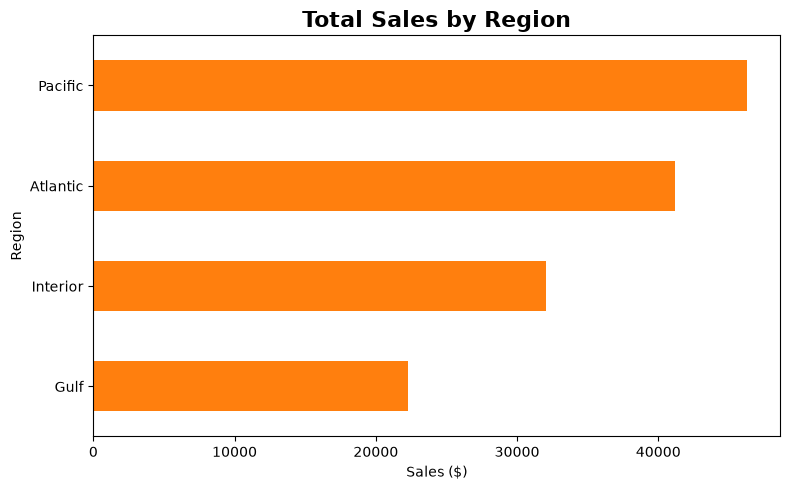

Region
Pacific     46301.53
Atlantic    41197.24
Interior    32037.60
Gulf        22247.26
Name: Sales, dtype: float64

In [35]:
region_sales = (
    df.groupby("Region")["Sales"]
      .sum()
      .sort_values()
)

plt.figure(figsize=(8,5))

region_sales.plot(
    kind="barh",
    color="#FF7F0E"
)

plt.title(
    "Total Sales by Region",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Sales ($)")
plt.ylabel("Region")

plt.tight_layout()

plt.savefig(
    figures_path/"sales_by_region.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

region_sales.sort_values(ascending=False)

### Observation

Sales performance varies considerably across geographical regions.

The Pacific region generates the highest revenue, followed closely by the Atlantic region. In contrast, the Gulf region contributes the lowest total sales.

This indicates that customer demand is concentrated in a limited number of geographical markets.

### Business Interpretation

High-performing regions such as Pacific and Atlantic should receive priority for inventory allocation, production planning, and marketing investment.

Lower-performing regions may require targeted promotional campaigns, pricing adjustments, or further investigation into customer demand and distribution efficiency before additional operational resources are allocated.

## Business Question

Which shipping modes generate the highest sales revenue?

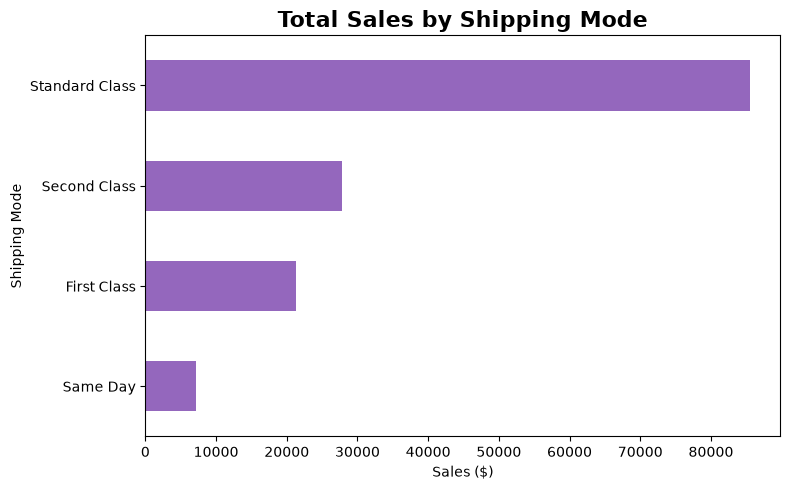

Ship Mode
Standard Class    85490.35
Second Class      27860.22
First Class       21319.39
Same Day           7113.67
Name: Sales, dtype: float64

In [36]:
shipping_sales = (
    df.groupby("Ship Mode")["Sales"]
      .sum()
      .sort_values()
)

plt.figure(figsize=(8,5))

shipping_sales.plot(
    kind="barh",
    color="#9467BD"
)

plt.title(
    "Total Sales by Shipping Mode",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Sales ($)")
plt.ylabel("Shipping Mode")

plt.tight_layout()

plt.savefig(
    figures_path/"sales_by_shipping_mode.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

shipping_sales.sort_values(ascending=False)

### Observation

Standard Class is the dominant shipping method, generating substantially higher sales than all other delivery options.

Second Class and First Class contribute moderate sales, while Same Day delivery represents only a small fraction of overall revenue.

This distribution suggests that customers generally prioritize lower shipping costs over faster delivery.

### Business Interpretation

Since Standard Class accounts for the majority of customer orders, warehouse operations and factory dispatch schedules should primarily be optimized around this shipping mode.

Resources allocated to premium shipping services should be balanced against their relatively low demand to avoid unnecessary operational costs while maintaining service quality.

## Business Question

How do sales vary across different months of the year?

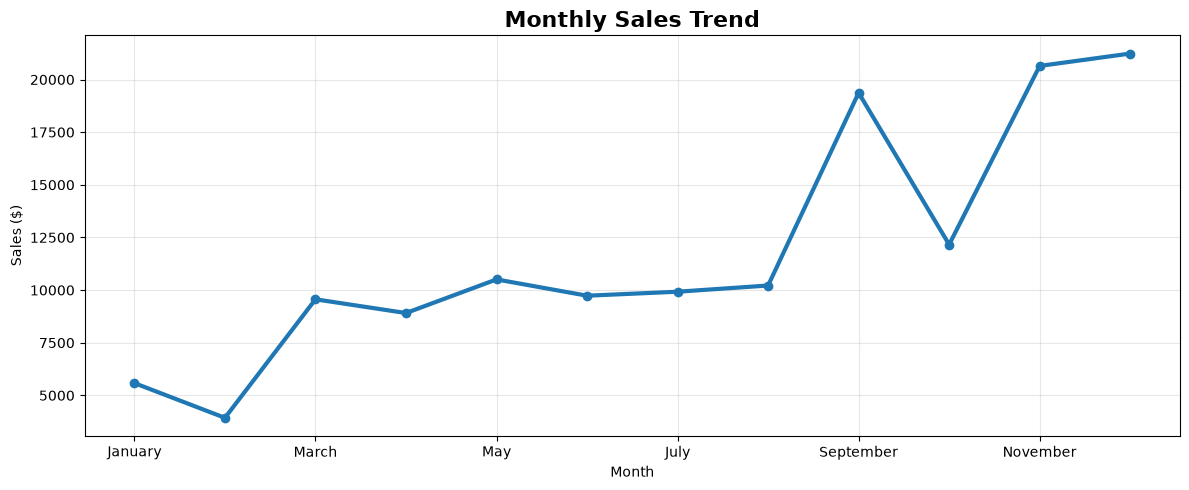

Order Month Name
January       5583.00
February      3933.52
March         9562.14
April         8910.66
May          10507.20
June          9733.69
July          9923.05
August       10217.75
September    19369.70
October      12161.87
November     20646.57
December     21234.48
Name: Sales, dtype: float64

In [37]:
monthly_sales = (
    df.groupby("Order Month Name")["Sales"]
      .sum()
      .reindex([
          "January","February","March","April",
          "May","June","July","August",
          "September","October","November","December"
      ])
)

plt.figure(figsize=(12,5))

monthly_sales.plot(
    marker="o",
    linewidth=3,
    color="#1F77B4"
)

plt.title(
    "Monthly Sales Trend",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Month")
plt.ylabel("Sales ($)")
plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    figures_path/"monthly_sales_trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

monthly_sales

### Observation

Monthly sales exhibit clear seasonal variation throughout the year.

Sales remain relatively consistent between March and August before increasing sharply in September. The highest revenue is observed during November and December, while February records the lowest sales.

These results indicate that customer demand is strongly influenced by seasonal purchasing behavior.

### Business Interpretation

Seasonal demand patterns should be incorporated into production and inventory planning.

Manufacturing capacity should gradually increase before the high-demand period beginning in September, while inventory levels and workforce requirements can be reduced during lower-demand months such as January and February. Proper seasonal planning can reduce stock shortages during peak periods and minimize excess inventory during slower months.

## Business Question

Which products achieve the highest average profit margin percentage?

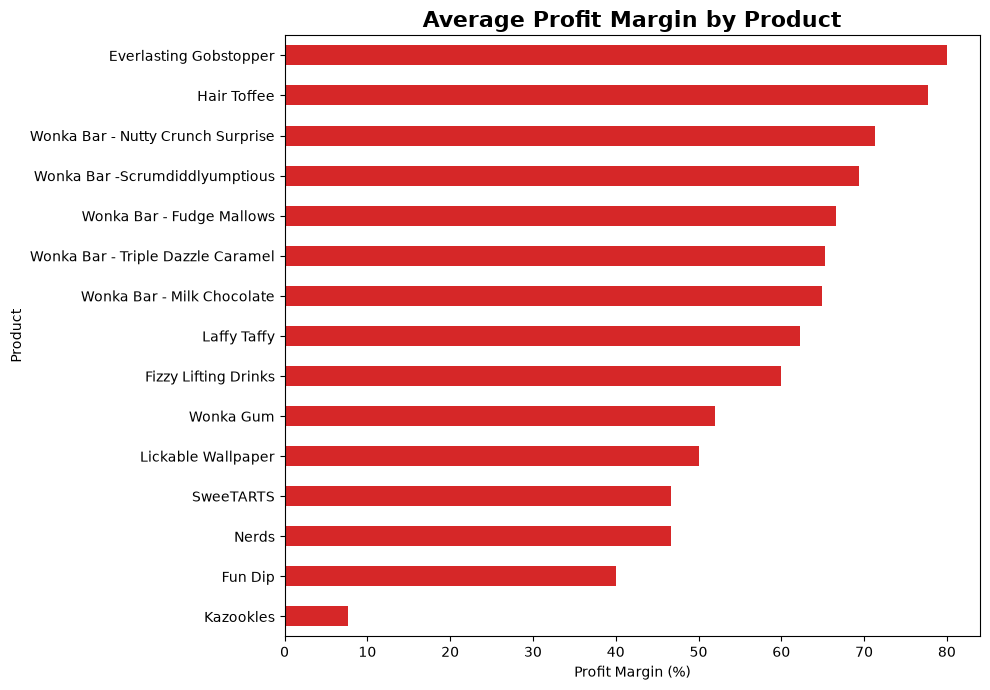

Product Name
Everlasting Gobstopper               80.000000
Hair Toffee                          77.777778
Wonka Bar - Nutty Crunch Surprise    71.346705
Wonka Bar -Scrumdiddlyumptious       69.444444
Wonka Bar - Fudge Mallows            66.666667
Wonka Bar - Triple Dazzle Caramel    65.333333
Wonka Bar - Milk Chocolate           64.923077
Laffy Taffy                          62.311558
Fizzy Lifting Drinks                 60.000000
Wonka Gum                            52.000000
Lickable Wallpaper                   50.000000
SweeTARTS                            46.666667
Nerds                                46.666667
Fun Dip                              40.000000
Kazookles                             7.692308
Name: Profit Margin (%), dtype: float64

In [38]:
profit_margin = (
    df.groupby("Product Name")["Profit Margin (%)"]
      .mean()
      .sort_values()
)

plt.figure(figsize=(10,7))

profit_margin.plot(
    kind="barh",
    color="#D62728"
)

plt.title(
    "Average Profit Margin by Product",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Profit Margin (%)")
plt.ylabel("Product")

plt.tight_layout()

plt.savefig(
    figures_path/"profit_margin_by_product.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

profit_margin.sort_values(ascending=False)

### Observation

Profit margins vary across products despite similar sales performance.

Several products achieve substantially higher average margins, indicating that they contribute more profit per dollar of revenue than other products.

This demonstrates that high sales volume does not necessarily imply high profitability efficiency.

### Business Interpretation

Products with consistently high profit margins should be prioritized during production planning because they maximize profitability while consuming similar manufacturing resources.

Low-margin products should be reviewed for pricing optimization, production cost reduction, or promotional strategies to improve their financial contribution.

## Business Question

Is there a relationship between product sales and gross profit?

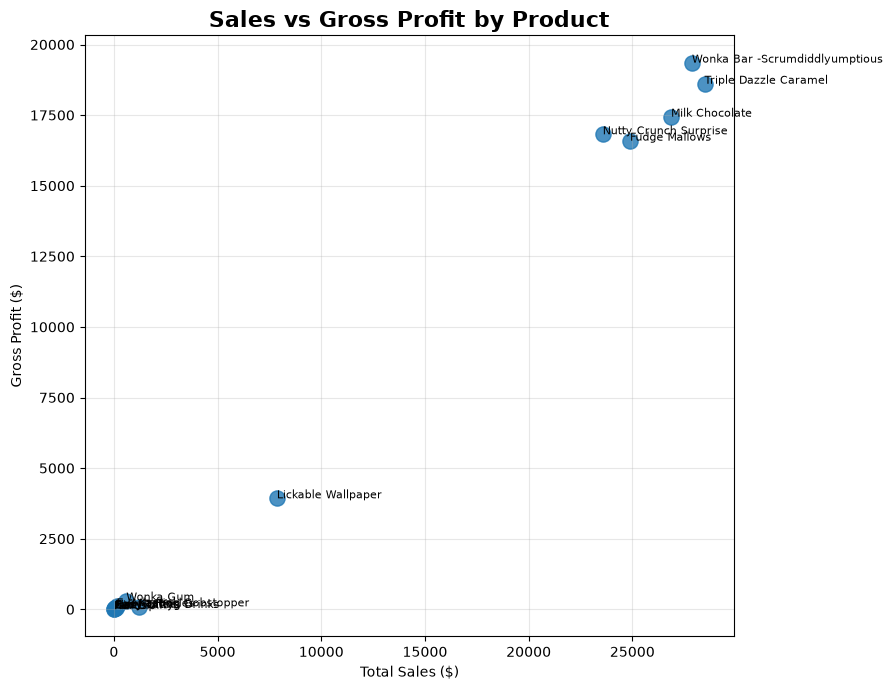

,Product Name,Sales,Gross Profit
0,Everlasting Gobstopper,130.00,104.00
1,Fizzy Lifting Drinks,78.75,47.25
2,Fun Dip,12.00,4.80
3,Hair Toffee,76.50,59.50
4,Kazookles,1205.75,92.75
5,Laffy Taffy,53.73,33.48
6,Lickable Wallpaper,7860.00,3930.00
7,Nerds,15.00,7.00
8,SweeTARTS,61.50,28.70
9,Wonka Bar - Fudge Mallows,24890.40,16593.60


In [39]:
summary = (
    df.groupby("Product Name")[["Sales", "Gross Profit"]]
      .sum()
      .reset_index()
)

plt.figure(figsize=(9,7))

plt.scatter(
    summary["Sales"],
    summary["Gross Profit"],
    s=120,
    alpha=0.8
)

for _, row in summary.iterrows():
    plt.text(
        row["Sales"],
        row["Gross Profit"],
        row["Product Name"].replace("Wonka Bar - ",""),
        fontsize=8
    )

plt.title(
    "Sales vs Gross Profit by Product",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Total Sales ($)")
plt.ylabel("Gross Profit ($)")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    figures_path/"sales_vs_profit.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

summary

### Observation

Products with higher sales generally produce higher gross profit, indicating a positive relationship between revenue generation and profitability.

However, the relationship is not perfectly linear, suggesting that some products achieve better profitability than others despite similar sales volumes.

### Business Interpretation

Comparing sales and profitability simultaneously enables managers to identify products that are both high-revenue and high-profit contributors.

These products represent strategic priorities for manufacturing, inventory planning, and long-term investment, while products with weaker profitability can be evaluated for operational improvements.